### Recurrent Neural Network (LSTM, V2)

This is a basic convolutional approach to sequence prediction using convolutions through TensorFlow!

We begin by important any relevant packages, modules, and the DataProcessor class (for our pre-processed data). Then we get our dataset ready.

In [2]:
import os, sys
sys.path.append(os.path.abspath('..'))  # add parent directory to sys.path
from data_cleanup import DataProcessor
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Define the windowing parameters
INPUT_WINDOW = 72
# Predict the next 24 hours
OUTPUT_WINDOW = 24 

# Initialize the class
processor = DataProcessor(input_steps=INPUT_WINDOW, output_steps=OUTPUT_WINDOW)

# Run the pipeline
(X_train, y_train), (X_val, y_val), (X_test, y_test) = processor.load_and_process_data()

# Check the final shapes
print("\n--- Final Data Shapes ---")
print(f"X_train shape: {X_train.shape}  | y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}     | y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}    | y_test shape:  {y_test.shape}")

Step 1/5: Fetching, cleaning, and engineering features...


/opt/anaconda3/envs/ds_env/lib/python3.11/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)
/Users/macychen/GithubProjects/ECS171G13/data_cleanup.py:135: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/Users/macychen/GithubProjects/ECS171G13/data_cleanup.py:175: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').agg(agg_dict)


Step 2/5: Resampling data to hourly and setting 'Global_active_power' as target...
Step 3/5: Splitting data and applying scaler...
Step 4/5: Creating time-series windows...
Step 5/5: Data processing complete.

--- Final Data Shapes ---
X_train shape: (25832, 72, 8)  | y_train shape: (25832, 24)
X_val shape:   (3529, 72, 8)     | y_val shape:   (3529, 24)
X_test shape:  (4943, 72, 8)    | y_test shape:  (4943, 24)


/Users/macychen/GithubProjects/ECS171G13/data_cleanup.py:176: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_hourly = df_hourly.fillna(method='ffill')


Next, we want to build the model itself. Keras makes this very simple at a high-level, so tuning is also easy to do.

In [6]:
from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed, Input

model = Sequential()

# --- ENCODER ---
# Process the 72 hours of history.
# We do NOT return sequences here; we want the final "state" vector that summarizes the past.
n_features = X_train.shape[2]
model.add(Input(shape=(INPUT_WINDOW, n_features)))
model.add(LSTM(64, return_sequences=False)) 

# --- BRIDGE ---
# Repeat the context vector 24 times (once for each output step).
# This prepares the data for the Decoder.
model.add(RepeatVector(OUTPUT_WINDOW))

# --- DECODER ---
# This LSTM processes the 24 steps. 
# return_sequences=True is CRITICAL here so we get an output for every hour.
model.add(LSTM(64, return_sequences=True))

# --- REGULARIZATION ---
# Increased dropout to stop the Validation Loss form spiking (Overfitting fix)
model.add(Dropout(0.3))

# --- OUTPUT ---
# TimeDistributed applies the Dense layer to every time step independently.
# This results in a shape of (Batch_Size, 24, 1)
model.add(TimeDistributed(Dense(1)))

model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])

Now we want to fit the model, train it, and determine an error metric.

In [7]:
# Early stopping to prevent overfitting
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Model architecture updated to Encoder-Decoder.")
model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[es],
    verbose=1
)
print("Training complete.")

print("Making predictions on the test set...")
predictions_scaled = model.predict(X_test)


unscaled_predictions = processor.inverse_transform_predictions(predictions_scaled)
unscaled_y_test = processor.inverse_transform_predictions(y_test)

# Check shapes to be sure (Optional debugging)
print(f"Shape before fix: {unscaled_predictions.shape}")

# If the data is 3D (e.g., [Rows, 24, 1]), squeeze it to 2D (e.g., [Rows, 24])
if unscaled_predictions.ndim == 3:
    unscaled_predictions = np.squeeze(unscaled_predictions)
    
if unscaled_y_test.ndim == 3:
    unscaled_y_test = np.squeeze(unscaled_y_test)

print(f"Shape after fix:  {unscaled_predictions.shape}")

mse = mean_squared_error(unscaled_y_test, unscaled_predictions)
print(f'\n--- Model Evaluation ---')
print(f'Test Set MSE (Mean Squared Error): {mse:.4f}')

# This is the human-readable version 
rmse = np.sqrt(mse)
print(f'Test Set RMSE (Root Mean Squared Error): {rmse:.4f}')
print(f'(This means, on average, the model was off by approx. {rmse:.2f} kilowatts)')

Model architecture updated to Encoder-Decoder.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 24, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 24, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,777 (202.25 KB)

 Trainable params: 51,777 (202.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
808/808 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - loss: 0.0190 - mae: 0.1075 - val_loss: 0.0182 - val_mae: 0.1081
Epoch 2/40
808/808 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - loss: 0.0174 - mae: 0.1017 - val_loss: 0.0142 - val_mae: 0.0929
Epoch 3/40
808/808 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - loss: 0.0148 - mae: 0.0911 - val_loss: 0.0130 - val_mae: 0.0873
Epoch 4/40
808/808 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - loss: 0.0136 - mae: 0.0861 - val_loss: 0.0131 - val_mae: 0.0857
Epoch 5/40
808/808 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - loss: 0.0132 - mae: 0.0841 - val_loss: 0.0130 - val_mae: 0.0859
Epoch 6/40
808/808 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - loss: 0.0128 - mae: 0.0828 - val_loss: 0.0127 - val_mae: 0.0858
Epoch 7/40
808/808 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - loss: 0.0125 - mae: 0.0816 - val_loss: 0.0128 - val_mae: 0.0849
Epoch 8/40
808/808 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - loss: 0.0123 - mae: 0.0806 - val_loss: 0.0127 - val_mae: 0.0846
Epoch 9/40
808/808 ━━━━━━━━━━━━━━━━━━━━ 

ValueError: could not broadcast input array from shape (118632,) into shape (4943,)

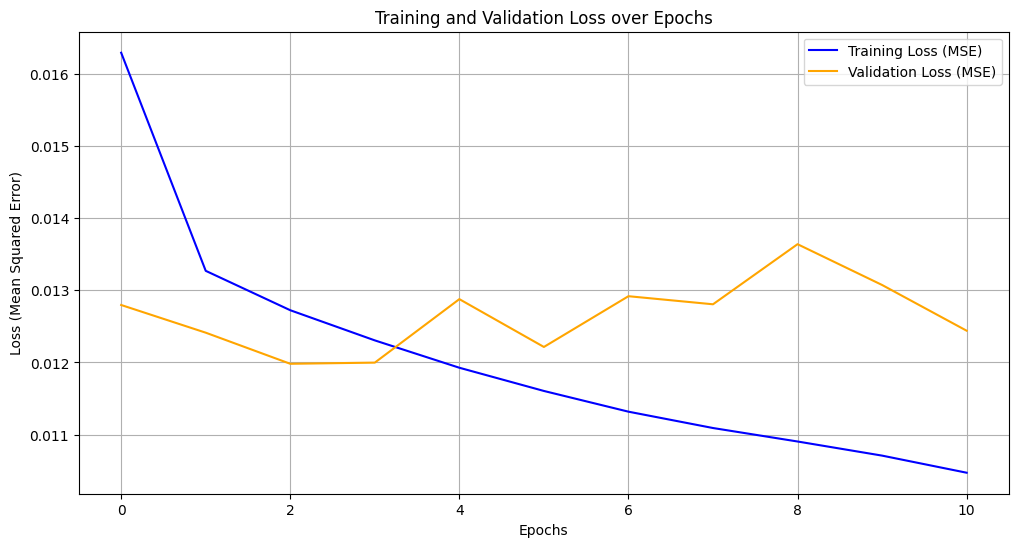

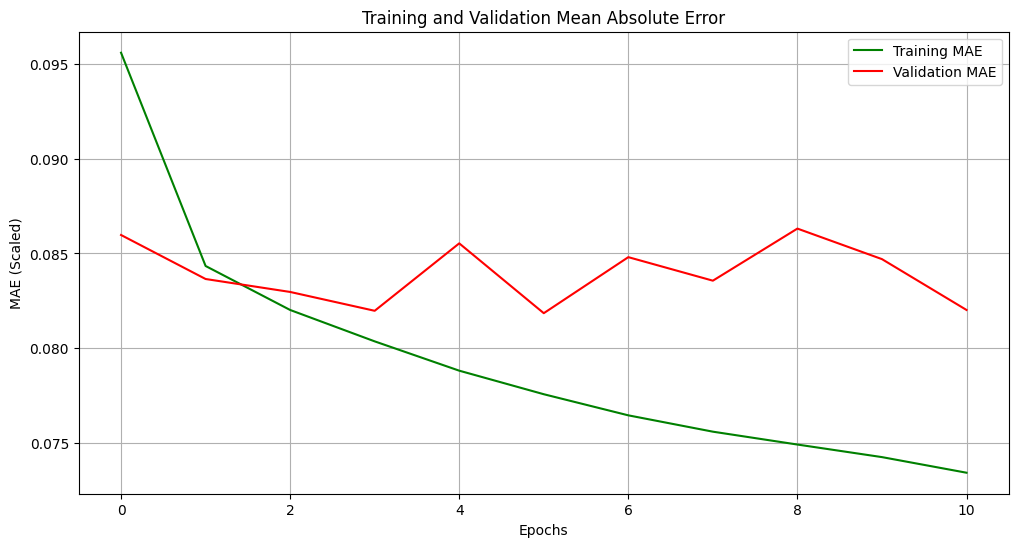

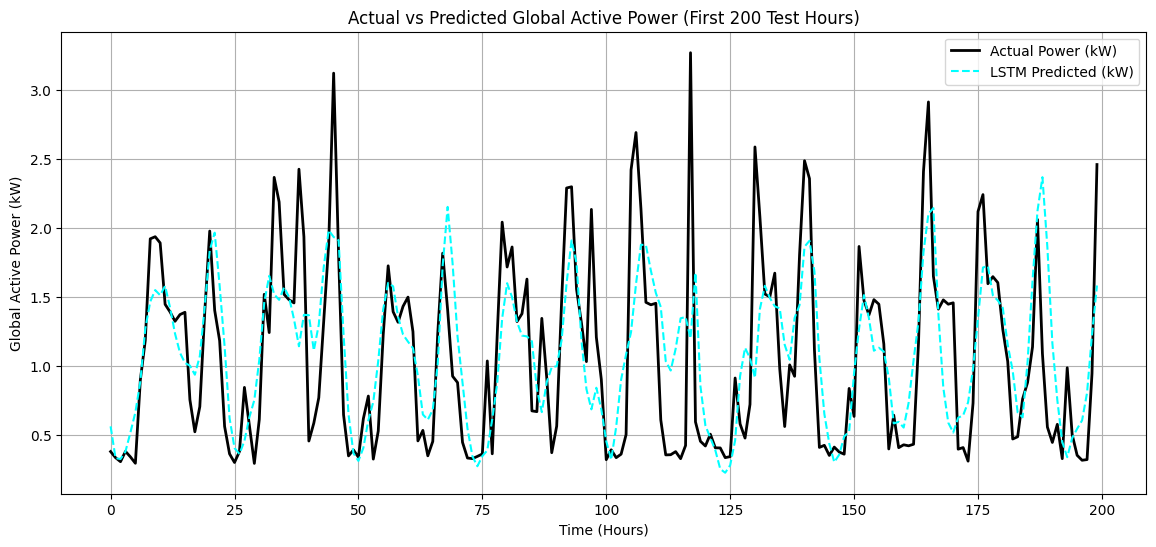

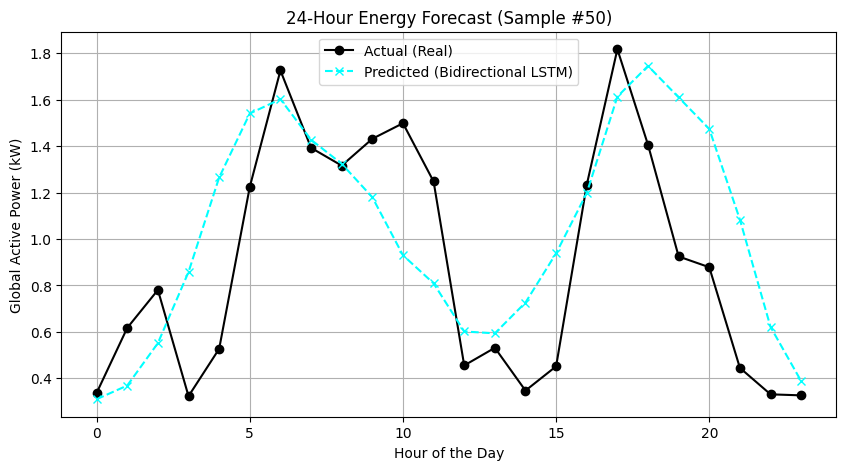

In [4]:
# Graph 1: Loss Curves (MSE)

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

# Graph 2: MAE Curves

plt.figure(figsize=(12, 6))
plt.plot(history.history['mae'], label='Training MAE', color='green')
plt.plot(history.history['val_mae'], label='Validation MAE', color='red')
plt.title('Training and Validation Mean Absolute Error')
plt.xlabel('Epochs')
plt.ylabel('MAE (Scaled)')
plt.legend()
plt.grid(True)
plt.show()

# Graph 3: Actual vs Predicted (Time Series)

# Since the model predicts 24 hours at a time, plotting all of them creates a messy web. 
# Instead, the standard way to plot a clean line is to take the first hour of every prediction window.

# We take the first 200 hours for a clean zoom-in (like the uploaded image)
subset_n = 200 

# Extract just the 1st hour prediction from each window (index 0)
# This reconstructs a continuous timeline
actual_trace = unscaled_y_test[:subset_n, 0]
pred_trace = unscaled_predictions[:subset_n, 0]

plt.figure(figsize=(14, 6))
plt.plot(actual_trace, label='Actual Power (kW)', color='black', linewidth=2)
plt.plot(pred_trace, label='LSTM Predicted (kW)', color='cyan', linestyle='--')
plt.title(f'Actual vs Predicted Global Active Power (First {subset_n} Test Hours)')
plt.xlabel('Time (Hours)')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True)
plt.show()

# Graph 4: Scatter Plot (Predicted vs Actual)

import matplotlib.pyplot as plt

# Let's pick a random day from the test set to visualize
# We can pick the 50th sample in the test set
sample_idx = 50

# Get the actual 24-hour sequence for this sample
real_24h = unscaled_y_test[sample_idx]

# Get the predicted 24-hour sequence for this sample
pred_24h = unscaled_predictions[sample_idx]

plt.figure(figsize=(10, 5))
plt.plot(real_24h, label='Actual (Real)', marker='o', color='black')
plt.plot(pred_24h, label='Predicted (Bidirectional LSTM)', marker='x', linestyle='--', color='cyan')

plt.title(f'24-Hour Energy Forecast (Sample #{sample_idx})')
plt.xlabel('Hour of the Day')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import numpy as np

FOLDS = 3
tscv = TimeSeriesSplit(n_splits=FOLDS)

cv_mse = []
cv_rmse = []

print("\nStarting Cross-Validation")

fold = 1
for train_idx, val_idx in tscv.split(X_train):

    print(f"\n----- Fold {fold} -----")

    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    model = Sequential()
    model.add(Input(shape=(INPUT_WINDOW, n_features)))
    model.add(LSTM(64, return_sequences=False))
    model.add(RepeatVector(OUTPUT_WINDOW))
    model.add(LSTM(64, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(TimeDistributed(Dense(1)))
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])

    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=40,
        batch_size=32,
        callbacks=[es],
        verbose=1
    )

    # Predict and evaluate on validation fold
    pred_scaled = model.predict(X_val_fold)
    pred_unscaled = processor.inverse_transform_predictions(pred_scaled)
    y_val_unscaled = processor.inverse_transform_predictions(y_val_fold)
    
    # Squeeze if needed
    if pred_unscaled.ndim == 3:
        pred_unscaled = np.squeeze(pred_unscaled)
    if y_val_unscaled.ndim == 3:
        y_val_unscaled = np.squeeze(y_val_unscaled)
    
    fold_mse = mean_squared_error(y_val_unscaled, pred_unscaled)
    fold_rmse = np.sqrt(fold_mse)
    
    print(f"Fold {fold} MSE: {fold_mse:.4f}, RMSE: {fold_rmse:.4f}")
    
    cv_mse.append(fold_mse)
    cv_rmse.append(fold_rmse)
    
    fold += 1

# Cross-Validation Summary
print("\nCross-Validation Summary")
print(f"Average MSE: {np.mean(cv_mse):.4f}")
print(f"Average RMSE: {np.mean(cv_rmse):.4f}")